<div style="text-align:center; color:#000000;">

<hr style="height:3px; background:#0066CC; border:none;">

<h1 style="font-size:44px; font-weight:800; margin:20px 0;">
LightSERNet: Speech Emotion Recognition
</h1>

<hr style="height:3px; background:#0066CC; border:none;">

</div>

# ==========================================================
# 1. Import Required Libraries
# ==========================================================

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,
                                     MaxPooling2D,
                                     BatchNormalization,
                                     ReLU,
                                     Dense,
                                     Dropout,
                                     GlobalAveragePooling2D)

from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)

print("="*60)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("Librosa Version    :", librosa.__version__)
print("="*60)

2026-07-02 14:30:37.823332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783002638.161543      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783002638.247910      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783002639.052451      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783002639.052493      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783002639.052496      58 computation_placer.cc:177] computation placer alr

TensorFlow Version : 2.19.0
NumPy Version      : 2.4.6
Librosa Version    : 0.11.0


# ==========================================================
# 2. Load and Explore the RAVDESS Dataset
# ==========================================================

RAVDESS Speech Emotion Dataset

Dataset Path
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24

Total Audio Files : 1440

Emotion Classes
Emotion
Surprise    192
Disgust     192
Fear        192
Sad         192
Happy       192
Calm        192
Angry       192
Neutral      96
Name: count, dtype: int64

Number of Actors : 24

Gender Distribution
Gender
Female    720
Male      720
Name: count, dtype: int64


,File Path,Emotion,Actor,Gender
0,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,Surprise,2,Female
1,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,Neutral,2,Female
2,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,Disgust,2,Female
3,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,Disgust,2,Female
4,/kaggle/input/datasets/uwrfkaggler/ravdess-emo...,Neutral,2,Female


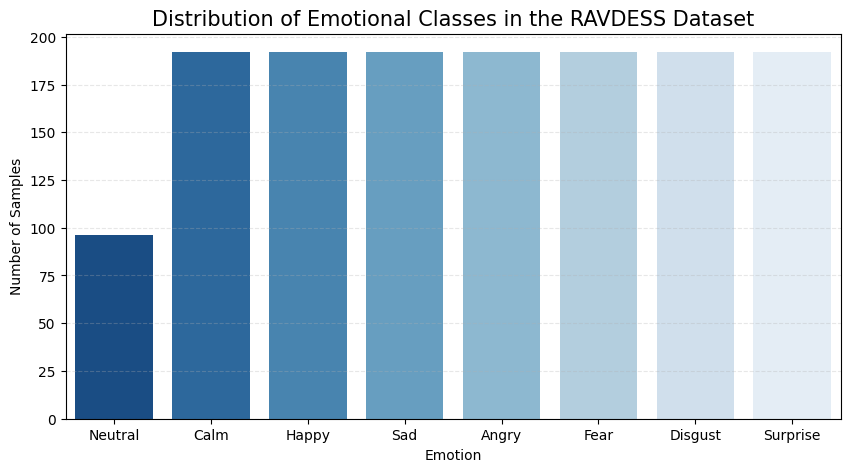

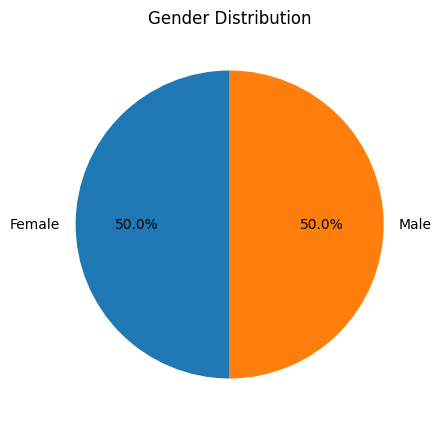

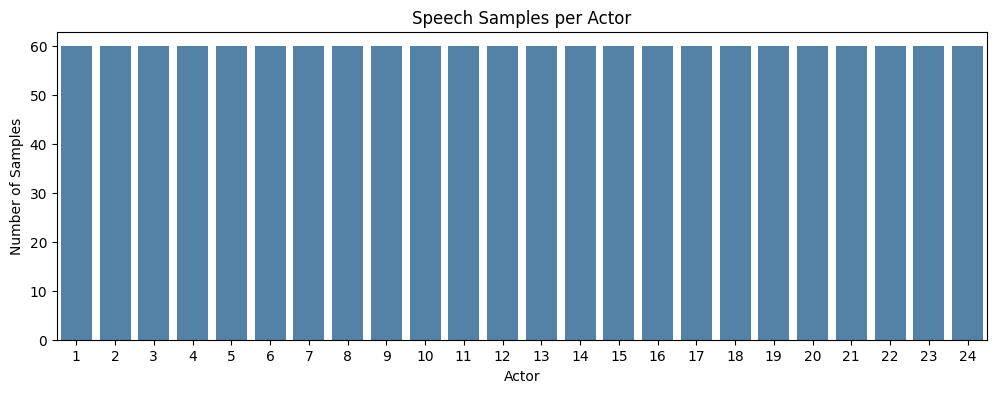

In [2]:


# ----------------------------------------------------------
# Dataset Path
# ----------------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24"

# ----------------------------------------------------------
# Emotion Labels
# ----------------------------------------------------------

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fear",
    "07": "Disgust",
    "08": "Surprise"
}

# ----------------------------------------------------------
# Read Dataset
# ----------------------------------------------------------

data = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            parts = file.split("-")

            emotion = emotion_map[parts[2]]

            actor = int(parts[-1].replace(".wav", ""))

            gender = "Female" if actor % 2 == 0 else "Male"

            data.append([
                file_path,
                emotion,
                actor,
                gender
            ])

# ----------------------------------------------------------
# Create DataFrame
# ----------------------------------------------------------

df = pd.DataFrame(
    data,
    columns=[
        "File Path",
        "Emotion",
        "Actor",
        "Gender"
    ]
)

# ----------------------------------------------------------
# Dataset Information
# ----------------------------------------------------------

print("="*70)
print("RAVDESS Speech Emotion Dataset")
print("="*70)

print("\nDataset Path")
print(DATASET_PATH)

print("\nTotal Audio Files :", len(df))

print("\nEmotion Classes")

print(df["Emotion"].value_counts())

print("\nNumber of Actors :", df["Actor"].nunique())

print("\nGender Distribution")

print(df["Gender"].value_counts())

print("="*70)

display(df.head())

# ----------------------------------------------------------
# Emotion Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Emotion",
    order=[
        "Neutral",
        "Calm",
        "Happy",
        "Sad",
        "Angry",
        "Fear",
        "Disgust",
        "Surprise"
    ],
    palette="Blues_r"
)

plt.title(
    "Distribution of Emotional Classes in the RAVDESS Dataset",
    fontsize=15
)

plt.xlabel("Emotion")

plt.ylabel("Number of Samples")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

# ----------------------------------------------------------
# Gender Distribution
# ----------------------------------------------------------

plt.figure(figsize=(5,5))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Gender Distribution")

plt.show()

# ----------------------------------------------------------
# Samples per Actor
# ----------------------------------------------------------

plt.figure(figsize=(12,4))

sns.countplot(
    data=df,
    x="Actor",
    color="steelblue"
)

plt.title("Speech Samples per Actor")

plt.xlabel("Actor")

plt.ylabel("Number of Samples")

plt.show()

# 4. Audio Signal Preprocessing

Original Samples        : 77988
Normalized Samples      : 77988
Silence Removed Samples : 31744
Pre-emphasized Samples  : 31744


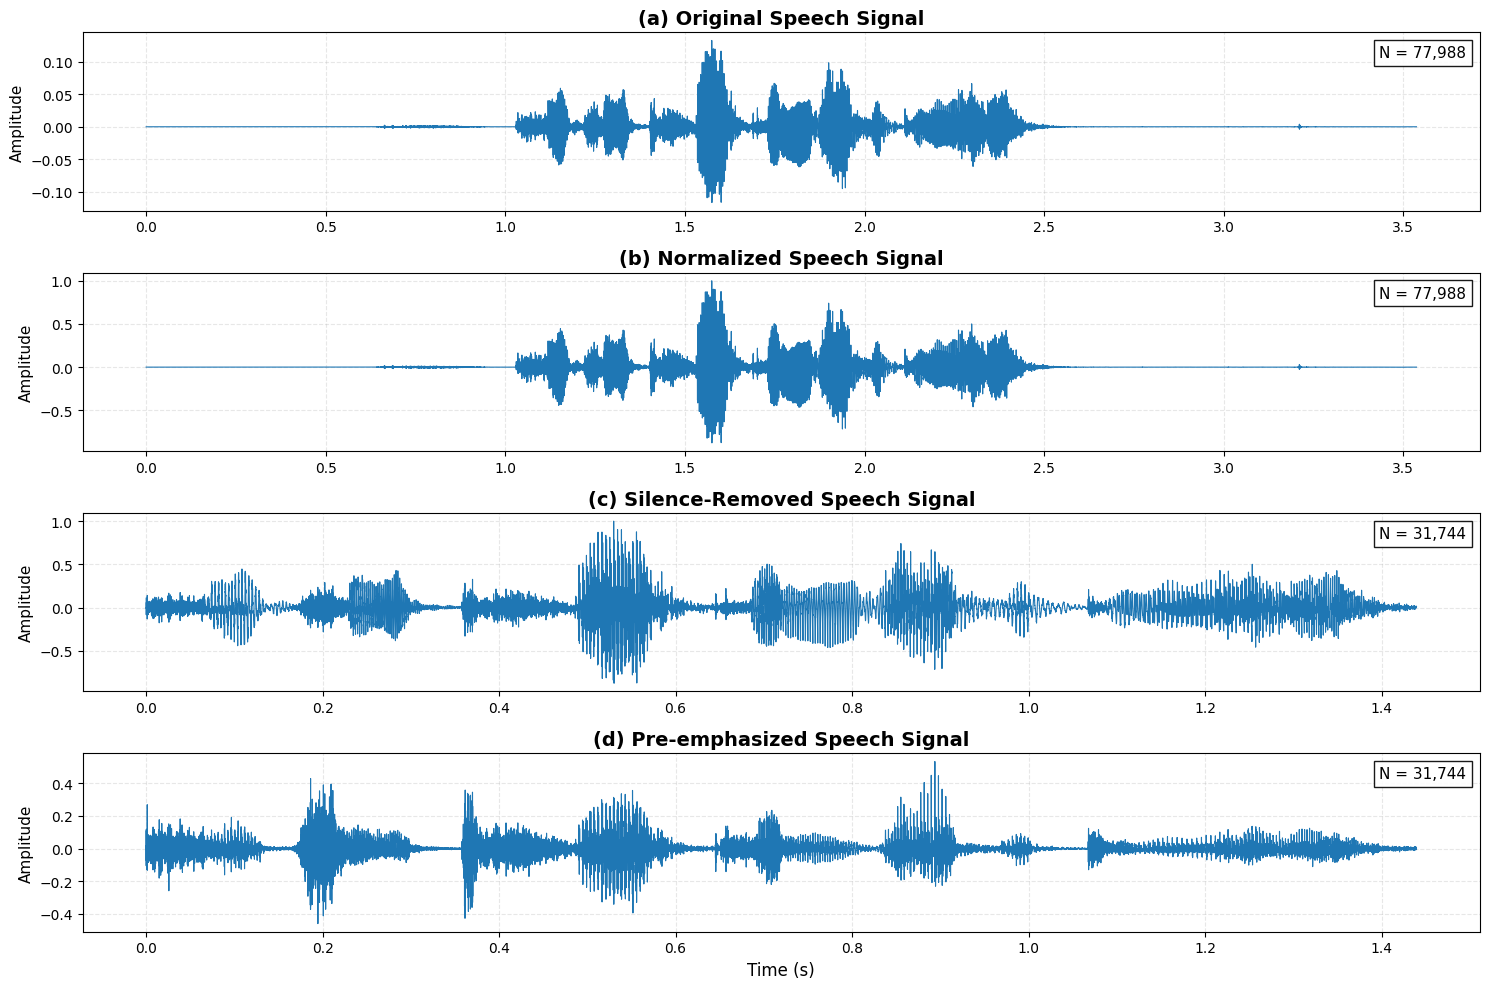

In [3]:
# ==========================================================
# 4. Audio Signal Preprocessing (Publication Quality)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# ----------------------------------------------------------
# Load One Sample Audio
# ----------------------------------------------------------

sample_file = df.iloc[0]["File Path"]

signal, sr = librosa.load(sample_file, sr=22050)

# ----------------------------------------------------------
# Step 1 : Original Signal
# ----------------------------------------------------------

original_signal = signal.copy()

# ----------------------------------------------------------
# Step 2 : Signal Normalization
# ----------------------------------------------------------

normalized_signal = librosa.util.normalize(original_signal)

# ----------------------------------------------------------
# Step 3 : Silence Removal
# ----------------------------------------------------------

trimmed_signal, _ = librosa.effects.trim(
    normalized_signal,
    top_db=20
)

# ----------------------------------------------------------
# Step 4 : Pre-emphasis
# ----------------------------------------------------------

pre_emphasized_signal = np.append(
    trimmed_signal[0],
    trimmed_signal[1:] - 0.97 * trimmed_signal[:-1]
)

# ----------------------------------------------------------
# Print Information
# ----------------------------------------------------------

print("="*70)
print("Original Samples        :", len(original_signal))
print("Normalized Samples      :", len(normalized_signal))
print("Silence Removed Samples :", len(trimmed_signal))
print("Pre-emphasized Samples  :", len(pre_emphasized_signal))
print("="*70)

# ----------------------------------------------------------
# Create Figure
# ----------------------------------------------------------

fig, ax = plt.subplots(
    4,
    1,
    figsize=(15,10)
)

signals = [

    (original_signal,
     "(a) Original Speech Signal",
     len(original_signal)),

    (normalized_signal,
     "(b) Normalized Speech Signal",
     len(normalized_signal)),

    (trimmed_signal,
     "(c) Silence-Removed Speech Signal",
     len(trimmed_signal)),

    (pre_emphasized_signal,
     "(d) Pre-emphasized Speech Signal",
     len(pre_emphasized_signal))

]

# ----------------------------------------------------------
# Plot Each Stage
# ----------------------------------------------------------

for i, (sig, title, samples) in enumerate(signals):

    time = np.arange(len(sig)) / sr

    ax[i].plot(
        time,
        sig,
        color="#1f77b4",
        linewidth=0.8
    )

    ax[i].set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax[i].grid(
        linestyle="--",
        alpha=0.3
    )

    # Only last subplot shows x-label

    if i < 3:
        ax[i].set_xlabel("")
    else:
        ax[i].set_xlabel(
            "Time (s)",
            fontsize=12
        )

    ax[i].set_ylabel(
        "Amplitude",
        fontsize=11
    )

    # Display sample length

    ax[i].text(
        0.99,
        0.86,
        f"N = {samples:,}",
        transform=ax[i].transAxes,
        ha="right",
        fontsize=11,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            alpha=0.9
        )
    )

# ----------------------------------------------------------
# Improve Layout
# ----------------------------------------------------------

plt.tight_layout()

# ----------------------------------------------------------
# Save Figure
# ----------------------------------------------------------

plt.savefig(
    "/kaggle/working/audio_preprocessing_pipeline.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 5. Acoustic Feature Extraction

MFCC Shape         : (40, 63)
Delta MFCC Shape   : (40, 63)
Delta² MFCC Shape  : (40, 63)
Mel Spectrogram    : (128, 63)


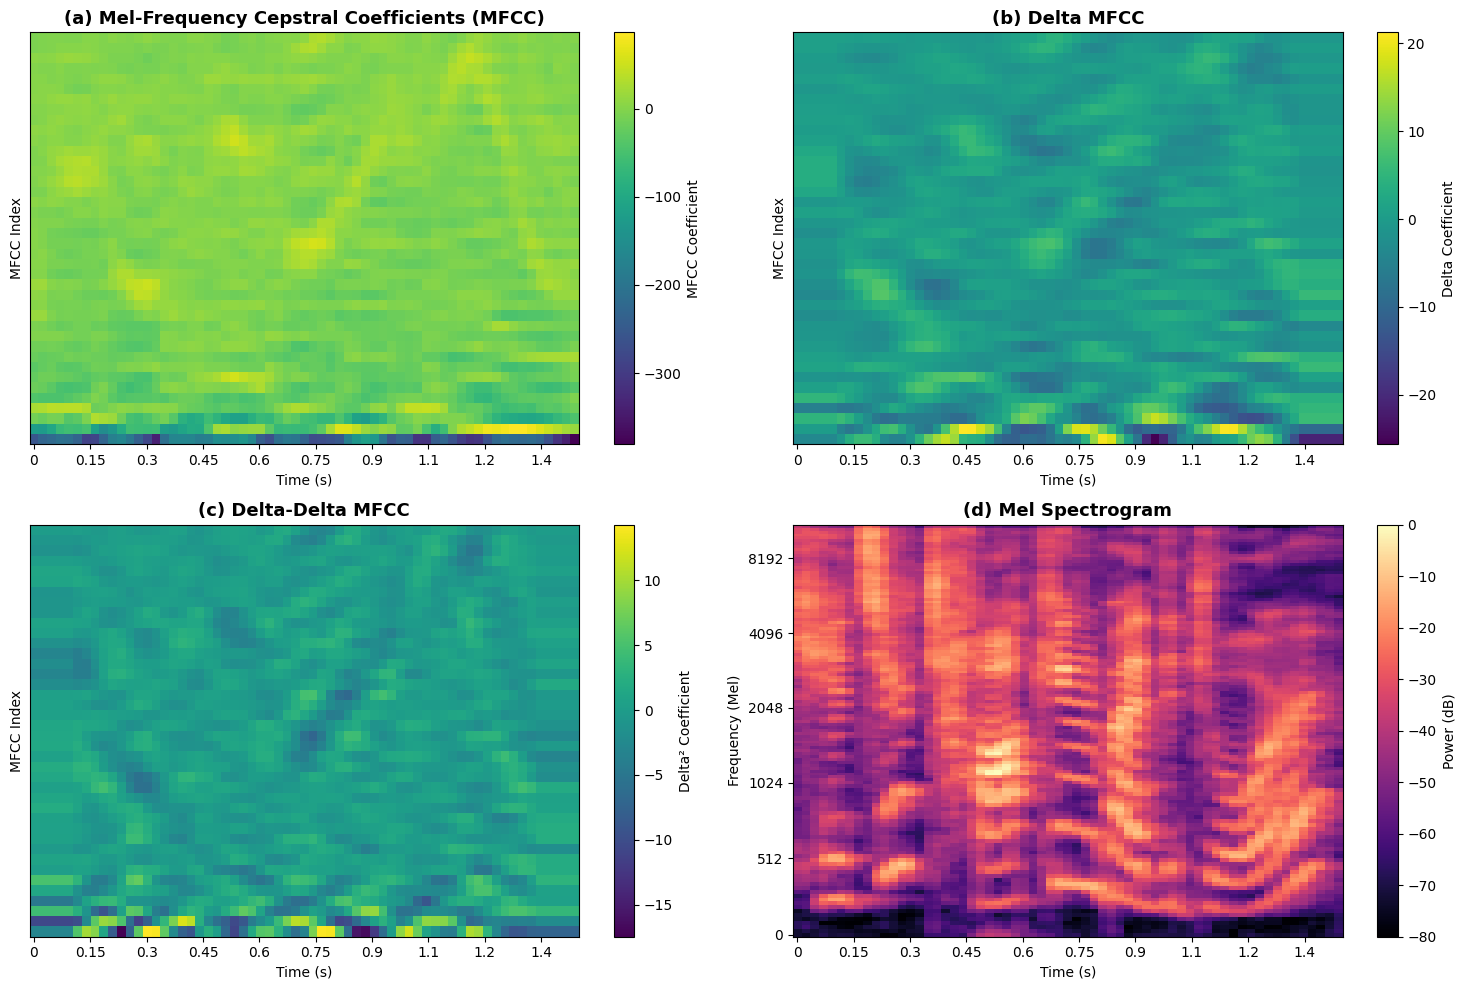

In [4]:
# ==========================================================
# 5. Multi-Level Acoustic Feature Extraction
# ==========================================================

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Load Sample Audio
# ----------------------------------------------------------

sample_file = df.iloc[0]["File Path"]

signal, sr = librosa.load(sample_file, sr=22050)

# ----------------------------------------------------------
# Audio Preprocessing
# ----------------------------------------------------------

signal = librosa.util.normalize(signal)

signal, _ = librosa.effects.trim(signal, top_db=20)

signal = np.append(
    signal[0],
    signal[1:] - 0.97 * signal[:-1]
)

# ----------------------------------------------------------
# Multi-Level Acoustic Feature Extraction
# ----------------------------------------------------------

# MFCC
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=40
)

# Delta MFCC
delta_mfcc = librosa.feature.delta(mfcc)

# Delta-Delta MFCC
delta2_mfcc = librosa.feature.delta(
    mfcc,
    order=2
)

# Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

# ----------------------------------------------------------
# Display Feature Dimensions
# ----------------------------------------------------------

print("="*70)

print("MFCC Shape         :", mfcc.shape)
print("Delta MFCC Shape   :", delta_mfcc.shape)
print("Delta² MFCC Shape  :", delta2_mfcc.shape)
print("Mel Spectrogram    :", mel_spec_db.shape)

print("="*70)

# ----------------------------------------------------------
# Publication Quality Figure
# ----------------------------------------------------------

fig, ax = plt.subplots(
    2,
    2,
    figsize=(15,10)
)

# ==========================================================
# (a) MFCC
# ==========================================================

img = librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis="time",
    cmap="viridis",
    ax=ax[0,0]
)

ax[0,0].set_title(
    "(a) Mel-Frequency Cepstral Coefficients (MFCC)",
    fontsize=13,
    fontweight="bold"
)

ax[0,0].set_xlabel("Time (s)")
ax[0,0].set_ylabel("MFCC Index")

cbar = fig.colorbar(img, ax=ax[0,0])
cbar.set_label("MFCC Coefficient")

# ==========================================================
# (b) Delta MFCC
# ==========================================================

img = librosa.display.specshow(
    delta_mfcc,
    sr=sr,
    x_axis="time",
    cmap="viridis",
    ax=ax[0,1]
)

ax[0,1].set_title(
    "(b) Delta MFCC",
    fontsize=13,
    fontweight="bold"
)

ax[0,1].set_xlabel("Time (s)")
ax[0,1].set_ylabel("MFCC Index")

cbar = fig.colorbar(img, ax=ax[0,1])
cbar.set_label("Delta Coefficient")

# ==========================================================
# (c) Delta-Delta MFCC
# ==========================================================

img = librosa.display.specshow(
    delta2_mfcc,
    sr=sr,
    x_axis="time",
    cmap="viridis",
    ax=ax[1,0]
)

ax[1,0].set_title(
    "(c) Delta-Delta MFCC",
    fontsize=13,
    fontweight="bold"
)

ax[1,0].set_xlabel("Time (s)")
ax[1,0].set_ylabel("MFCC Index")

cbar = fig.colorbar(img, ax=ax[1,0])
cbar.set_label("Delta² Coefficient")

# ==========================================================
# (d) Mel Spectrogram
# ==========================================================

img = librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    cmap="magma",
    ax=ax[1,1]
)

ax[1,1].set_title(
    "(d) Mel Spectrogram",
    fontsize=13,
    fontweight="bold"
)

ax[1,1].set_xlabel("Time (s)")
ax[1,1].set_ylabel("Frequency (Mel)")

cbar = fig.colorbar(img, ax=ax[1,1])
cbar.set_label("Power (dB)")

# ----------------------------------------------------------
# Improve Layout
# ----------------------------------------------------------

plt.tight_layout()

# ----------------------------------------------------------
# Save Figure
# ----------------------------------------------------------

plt.savefig(
    "/kaggle/working/multi_level_acoustic_features.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

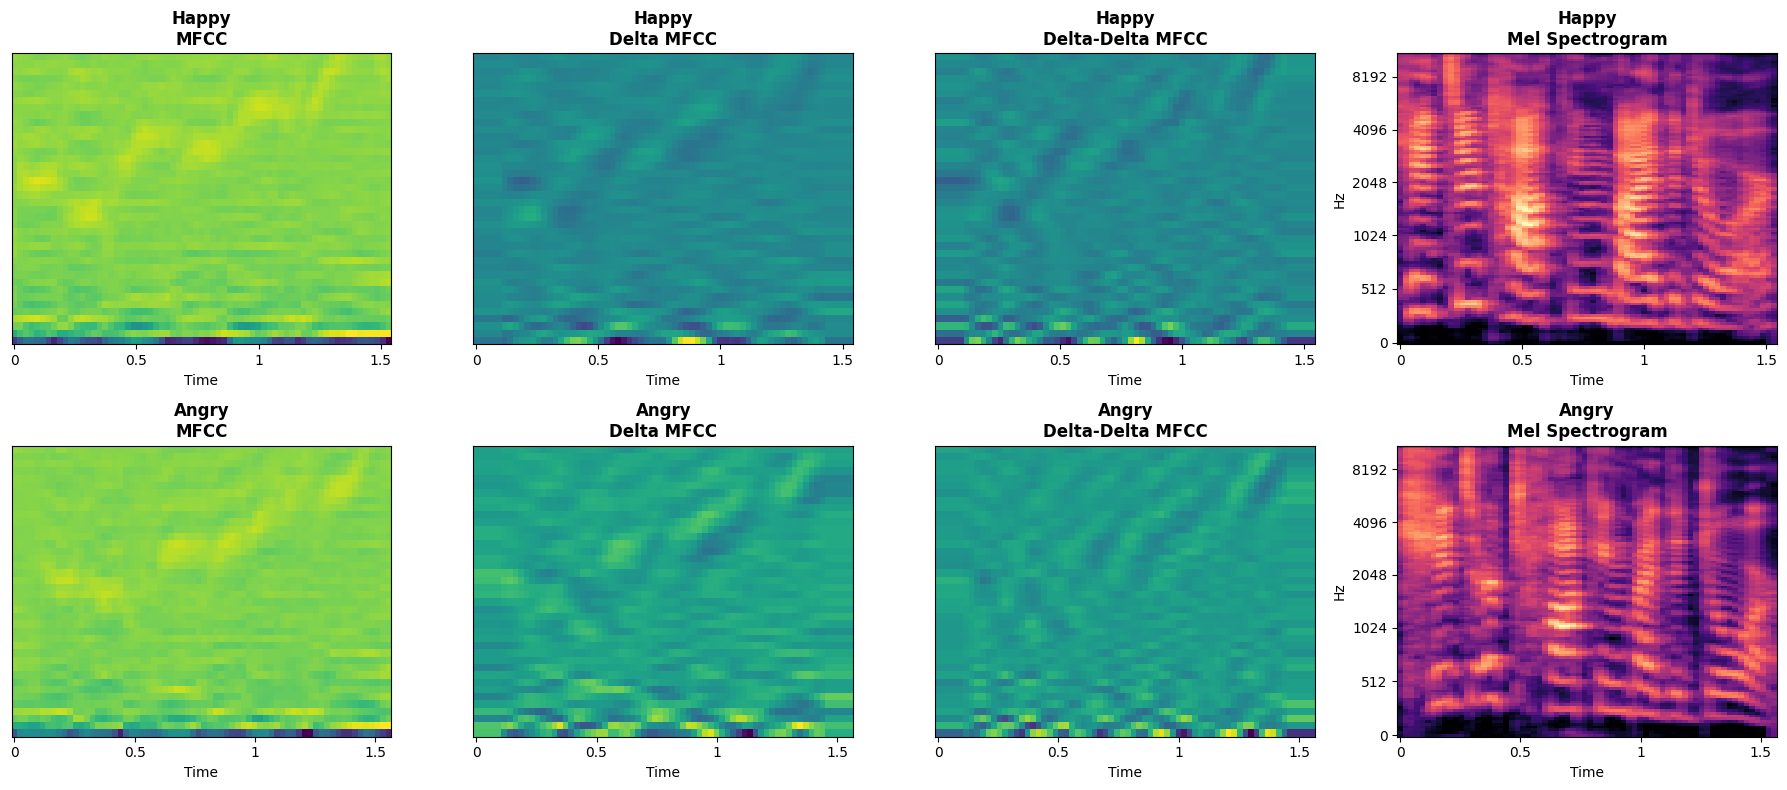

In [5]:
# ==========================================================
# Compare Two Emotions (Happy vs Angry)
# Multi-Level Acoustic Feature Visualization
# ==========================================================

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Select One Happy and One Angry Sample
# ----------------------------------------------------------

happy_file = df[df["Emotion"]=="Happy"].iloc[0]["File Path"]
angry_file = df[df["Emotion"]=="Angry"].iloc[0]["File Path"]

files = {
    "Happy": happy_file,
    "Angry": angry_file
}

fig, ax = plt.subplots(
    2,
    4,
    figsize=(18,8)
)

for row,(emotion,file) in enumerate(files.items()):

    signal,sr = librosa.load(file,sr=22050)

    # preprocessing
    signal = librosa.util.normalize(signal)

    signal,_ = librosa.effects.trim(signal,top_db=20)

    signal = np.append(
        signal[0],
        signal[1:] - 0.97*signal[:-1]
    )

    # ---------------- MFCC ----------------

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    img = librosa.display.specshow(
        mfcc,
        sr=sr,
        x_axis="time",
        cmap="viridis",
        ax=ax[row,0]
    )

    ax[row,0].set_title(
        f"{emotion}\nMFCC",
        fontsize=12,
        fontweight="bold"
    )

    # ---------------- Delta ----------------

    delta = librosa.feature.delta(mfcc)

    librosa.display.specshow(
        delta,
        sr=sr,
        x_axis="time",
        cmap="viridis",
        ax=ax[row,1]
    )

    ax[row,1].set_title(
        f"{emotion}\nDelta MFCC",
        fontsize=12,
        fontweight="bold"
    )

    # ---------------- Delta² ----------------

    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    librosa.display.specshow(
        delta2,
        sr=sr,
        x_axis="time",
        cmap="viridis",
        ax=ax[row,2]
    )

    ax[row,2].set_title(
        f"{emotion}\nDelta-Delta MFCC",
        fontsize=12,
        fontweight="bold"
    )

    # ---------------- Mel ----------------

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        cmap="magma",
        ax=ax[row,3]
    )

    ax[row,3].set_title(
        f"{emotion}\nMel Spectrogram",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "/kaggle/working/feature_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 6. Input Feature Tensor Construction

In [6]:
# ==========================================================
# 6.1 Input Feature Tensor Construction
# ==========================================================

import os
import cv2
import librosa
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Initialize Dataset
# ----------------------------------------------------------

X = []
y = []

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fear",
    "07": "Disgust",
    "08": "Surprise"
}

TARGET_HEIGHT = 40
TARGET_WIDTH = 63

# ----------------------------------------------------------
# Process Every Audio File
# ----------------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24"

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Total Audio Files:", len(audio_files))

for file_path in audio_files:
    
    # -----------------------------
    # Load Audio
    # -----------------------------

    signal, sr = librosa.load(
        file_path,
        sr=22050
    )

    # -----------------------------
    # Audio Preprocessing
    # -----------------------------

    signal = librosa.util.normalize(signal)

    signal, _ = librosa.effects.trim(
        signal,
        top_db=20
    )

    signal = np.append(
        signal[0],
        signal[1:] - 0.97 * signal[:-1]
    )

    # -----------------------------
    # Feature Extraction
    # -----------------------------

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    delta = librosa.feature.delta(mfcc)

    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=128
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # -----------------------------
    # Resize Features
    # -----------------------------

    mfcc = cv2.resize(
        mfcc,
        (TARGET_WIDTH, TARGET_HEIGHT)
    )

    delta = cv2.resize(
        delta,
        (TARGET_WIDTH, TARGET_HEIGHT)
    )

    delta2 = cv2.resize(
        delta2,
        (TARGET_WIDTH, TARGET_HEIGHT)
    )

    mel = cv2.resize(
        mel,
        (TARGET_WIDTH, TARGET_HEIGHT)
    )

    # -----------------------------
    # Create Input Tensor
    # -----------------------------

    tensor = np.stack(
        [
            mfcc,
            delta,
            delta2,
            mel
        ],
        axis=-1
    )

    # -----------------------------
    # Channel-wise Normalization
    # -----------------------------

    # for c in range(4):

    #     mean = np.mean(tensor[:, :, c])
    #     std = np.std(tensor[:, :, c]) + 1e-8

    #     tensor[:, :, c] = (
    #         tensor[:, :, c] - mean
    #     ) / std

    # -----------------------------
    # Save ONE Sample
    # -----------------------------

    X.append(tensor)

    emotion = os.path.basename(
        file_path
    ).split("-")[2]

    y.append(
        emotion_map[emotion]
    )

# ----------------------------------------------------------
# Convert to NumPy
# ----------------------------------------------------------

X = np.asarray(
    X,
    dtype=np.float32
)

y = np.asarray(y)

print("="*60)
print("Feature Tensor Shape :", X.shape)
print("Labels Shape         :", y.shape)
print("="*60)

# ----------------------------------------------------------
# Encode Labels
# ----------------------------------------------------------

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

# ----------------------------------------------------------
# Train / Validation / Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.20,

    stratify=y_train,

    random_state=42

)

print("\nDataset Split")
print("---------------------------")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

# ----------------------------------------------------------
# Verify Split
# ----------------------------------------------------------

assert X_train.shape[0] == 921
assert X_val.shape[0] == 231
assert X_test.shape[0] == 288

print("\nDataset verified successfully.")

Total Audio Files: 1440
Feature Tensor Shape : (1440, 40, 63, 4)
Labels Shape         : (1440,)
['Angry' 'Calm' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprise']

Dataset Split
---------------------------
Training   : (921, 40, 63, 4)
Validation : (231, 40, 63, 4)
Testing    : (288, 40, 63, 4)

Dataset verified successfully.


In [7]:
# ==========================================================
# 6.2 Dataset-Level Feature Normalization
# ==========================================================

# Compute channel-wise statistics from the whole dataset
mean = np.mean(
    X,
    axis=(0,1,2),
    keepdims=True
)

std = np.std(
    X,
    axis=(0,1,2),
    keepdims=True
) + 1e-8

# Normalize
X = (X - mean) / std

print("="*60)
print("Dataset Normalization Completed")
print("Feature Mean Shape :", mean.shape)
print("Feature Std Shape  :", std.shape)
print("="*60)

Dataset Normalization Completed
Feature Mean Shape : (1, 1, 1, 4)
Feature Std Shape  : (1, 1, 1, 4)


In [8]:
# ==========================================================
# 6.3 Train / Validation / Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

Training   : (921, 40, 63, 4)
Validation : (231, 40, 63, 4)
Testing    : (288, 40, 63, 4)


In [9]:
# ==========================================================
# 6.4 Verify Dataset Distribution
# ==========================================================

import numpy as np

print("="*60)
print("Training Samples")
print(np.bincount(y_train))

print("\nValidation Samples")
print(np.bincount(y_val))

print("\nTesting Samples")
print(np.bincount(y_test))

print("="*60)
print("Emotion Classes")
print(label_encoder.classes_)
print("="*60)

Training Samples
[123 123 123 123 122  62 123 122]

Validation Samples
[31 31 31 30 31 15 31 31]

Testing Samples
[38 38 38 39 39 19 38 39]
Emotion Classes
['Angry' 'Calm' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprise']


# 7. Proposed LightSERNet Architecture

## Residual Depthwise Block

In [10]:
# ==========================================================
# Residual Depthwise Convolution Block
# ==========================================================

def residual_depthwise_block(inputs, filters):

    shortcut = inputs

    # Depthwise Convolution
    x = DepthwiseConv2D(
        kernel_size=(3,3),
        padding="same",
        use_bias=False
    )(inputs)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # Pointwise Convolution
    x = Conv2D(
        filters,
        kernel_size=(1,1),
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)

    # Match channels if required
    if inputs.shape[-1] != filters:

        shortcut = Conv2D(
            filters,
            kernel_size=(1,1),
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = BatchNormalization()(shortcut)

    # Residual Connection
    x = Add()([x, shortcut])

    x = ReLU()(x)

    return x

print("Residual Block Ready")

Residual Block Ready


# 7.1 — Input Layer

In [11]:
# ==========================================================
# 7.1 Input Layer
# ==========================================================

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    BatchNormalization,
    ReLU,
    Add,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

# ----------------------------------------------------------
# Input Feature Tensor
# ----------------------------------------------------------

input_layer = Input(
    shape=(40, 63, 4),
    name="Input_Feature_Tensor"
)

print("="*60)
print("LightSERNet Input Layer Created Successfully")
print("Input Shape :", input_layer.shape)
print("="*60)

LightSERNet Input Layer Created Successfully
Input Shape : (None, 40, 63, 4)


# 7.2 — Initial Convolution Block

In [12]:
# ==========================================================
# 7.2 Initial Convolution Block
# ==========================================================

x = Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding="same",
    use_bias=False,
    name="Conv_Block_1"
)(input_layer)

x = BatchNormalization(
    name="BN_1"
)(x)

x = ReLU(
    name="ReLU_1"
)(x)

x = MaxPooling2D(
    pool_size=(2,2),
    name="MaxPool_1"
)(x)

print("Initial Convolution Block Created.")

Initial Convolution Block Created.


2026-07-02 14:32:38.056259: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 7.3 — Residual Block 1

In [13]:
# ==========================================================
# 7.3 Residual Block 1
# ==========================================================

x = residual_depthwise_block(
    x,
    filters=32
)

print("Residual Block 1 Created.")

Residual Block 1 Created.


# 7.4 — Second Convolution Block

In [14]:
# ==========================================================
# 7.4 Second Convolution Block
# ==========================================================

x = Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding="same",
    use_bias=False,
    name="Conv_Block_2"
)(x)

x = BatchNormalization(name="BN_2")(x)

x = ReLU(name="ReLU_2")(x)

x = MaxPooling2D(
    pool_size=(2,2),
    name="MaxPool_2"
)(x)

print("Second Convolution Block Created.")

Second Convolution Block Created.


# 7.5 — Residual Block 2

In [15]:
# ==========================================================
# 7.5 Residual Block 2
# ==========================================================

x = residual_depthwise_block(
    x,
    filters=64
)

print("Residual Block 2 Created.")

Residual Block 2 Created.


# 7.6 Third Convolution Block

In [16]:
# ==========================================================
# 7.6 Third Convolution Block
# ==========================================================

x = Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding="same",
    use_bias=False,
    name="Conv_Block_3"
)(x)

x = BatchNormalization(name="BN_3")(x)

x = ReLU(name="ReLU_3")(x)

print("Third Convolution Block Created.")

Third Convolution Block Created.


# 7.7 Residual Block 3

In [17]:
# ==========================================================
# 7.7 Residual Block 3
# ==========================================================

x = residual_depthwise_block(
    x,
    filters=128
)

print("Residual Block 3 Created.")

Residual Block 3 Created.


# 7.8 Classification Head

In [18]:
# ==========================================================
# 7.8 Classification Head
# ==========================================================

x = GlobalAveragePooling2D(
    name="Global_Average_Pooling"
)(x)

x = Dense(
    64,
    activation="relu",
    name="Dense_64"
)(x)

x = Dropout(
    0.4,
    name="Dropout"
)(x)

output_layer = Dense(
    8,
    activation="softmax",
    name="Emotion_Output"
)(x)

print("Classification Head Created.")

Classification Head Created.


# 7.9 Build LightSERNet

In [19]:
# ==========================================================
# 7.9 Build LightSERNet
# ==========================================================

LightSERNet = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LightSERNet"
)

print("LightSERNet Successfully Built.")

LightSERNet Successfully Built.


# 7.10 Model Summary

In [20]:
# ==========================================================
# 7.10 Model Summary
# ==========================================================

LightSERNet.summary()

Model: "LightSERNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Feature_Tens… │ (None, 40, 63, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_Block_1        │ (None, 40, 63,    │      1,152 │ Input_Feature_Te… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_1                │ (None, 40, 63,    │        128 │ Conv_Block_1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ReLU_1 (ReLU)       │ (None, 40, 63,    │          0 │ BN_1[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_1           │ (None, 20, 31,    │          0 │ ReLU_1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 20, 31,    │        288 │ MaxPool_1[0][0]   │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 20, 31,    │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 20, 31,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 20, 31,    │      1,024 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 31,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 31,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ MaxPool_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 20, 31,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv_Block_2        │ (None, 20, 31,    │     18,432 │ re_lu_1[0][0]     │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_2                │ (None, 20, 31,    │        256 │ Conv_Block_2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ReLU_2 (ReLU)       │ (None, 20, 31,    │          0 │ BN_2[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_2           │ (None, 10, 15,    │          0 │ ReLU_2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 10, 15,    │        576 │ MaxPool_2[0][0] 

 Total params: 128,296 (501.16 KB)

 Trainable params: 126,952 (495.91 KB)

 Non-trainable params: 1,344 (5.25 KB)

# 7.11 Compute Class Weights

In [21]:
# ==========================================================
# 7.11 Compute Class Weights
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    i: weights[i]
    for i in range(len(weights))
}

print("="*60)
print("Class Weights")
print(class_weights)
print("="*60)

Class Weights
{0: np.float64(0.9359756097560976), 1: np.float64(0.9359756097560976), 2: np.float64(0.9359756097560976), 3: np.float64(0.9359756097560976), 4: np.float64(0.9436475409836066), 5: np.float64(1.8568548387096775), 6: np.float64(0.9359756097560976), 7: np.float64(0.9436475409836066)}


# 8. Model Compilation and Training

# 8.1 Compile LightSERNet

In [22]:
# ==========================================================
# 8.1 Compile LightSERNet
# ==========================================================

from tensorflow.keras.optimizers import Adam

LightSERNet.compile(

    optimizer=Adam(
        learning_rate=0.0005
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("="*60)
print("LightSERNet Compiled Successfully")
print("="*60)

LightSERNet Compiled Successfully


# 8.2 Training Callbacks

In [23]:
# ==========================================================
# 8.2 Training Callbacks
# ==========================================================

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ReduceLROnPlateau,

    ModelCheckpoint

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    verbose=1

)

checkpoint = ModelCheckpoint(

    filepath="best_lightsernet.keras",

    monitor="val_loss",

    mode="min",

    save_best_only=True,

    verbose=1

)

print("Callbacks Created Successfully")

Callbacks Created Successfully


# 8.3 Train LightSERNet

In [24]:
history = LightSERNet.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=60,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.1443 - loss: 2.3040
Epoch 1: val_loss improved from None to 2.05657, saving model to best_lightsernet.keras

Epoch 1: finished saving model to best_lightsernet.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.1900 - loss: 2.1257 - val_accuracy: 0.1342 - val_loss: 2.0566 - learning_rate: 5.0000e-04
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.2871 - loss: 1.8247
Epoch 2: val_loss did not improve from 2.05657
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.3062 - loss: 1.8079 - val_accuracy: 0.1732 - val_loss: 2.0652 - learning_rate: 5.0000e-04
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3503 - loss: 1.6814
Epoch 3: val_loss did not improve from 2.05657
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.3735 - loss: 1.6611 - val_accuracy: 0.1342 - val_loss: 2.0957 - learning_rate: 5.0000e-04
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.

In [25]:
test_loss, test_accuracy = LightSERNet.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Accuracy :", test_accuracy)
print("Test Loss :", test_loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6458 - loss: 0.9667
Test Accuracy : 0.6458333134651184
Test Loss : 0.9667189717292786


# Save Final Model

In [26]:
# ==========================================================
# Save Final Model
# ==========================================================

LightSERNet.save(

    "emotion_recognition_model.keras"

)

LightSERNet.save(

    "emotion_recognition_model.h5"

)

print("Model Saved Successfully.")

Model Saved Successfully.


# 9. Experimental Results

# 9.1 Training Accuracy Curve

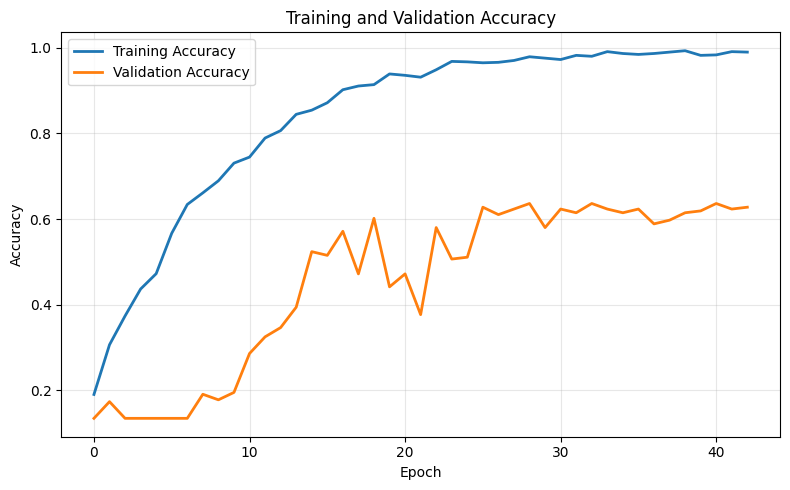

In [27]:
# ==========================================================
# 9.1 Training Accuracy Curve
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_accuracy_curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 9.2 Training Loss Curve

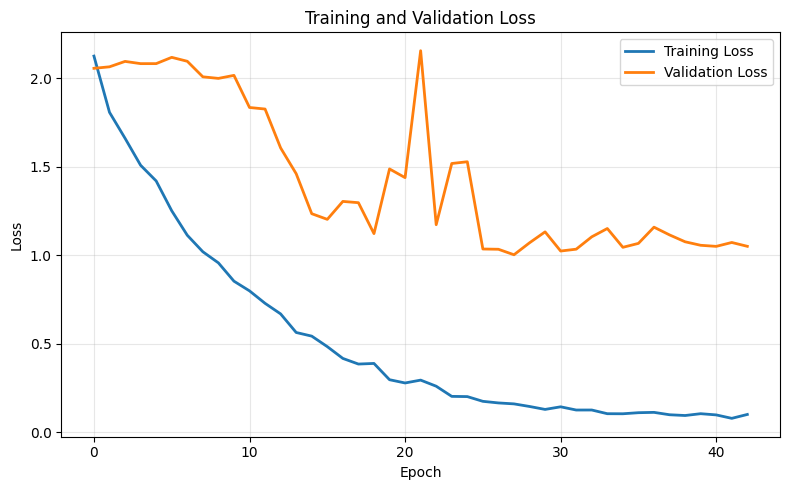

In [28]:
# ==========================================================
# 9.2 Training Loss Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_loss_curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 9.3 Evaluate Model

In [29]:
# ==========================================================
# 9.3 Evaluate Model
# ==========================================================

test_loss, test_accuracy = LightSERNet.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("="*60)
print("Test Accuracy :", test_accuracy)
print("Test Loss     :", test_loss)
print("="*60)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6458 - loss: 0.9667
Test Accuracy : 0.6458333134651184
Test Loss     : 0.9667189717292786


# 9.4 Confusion Matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


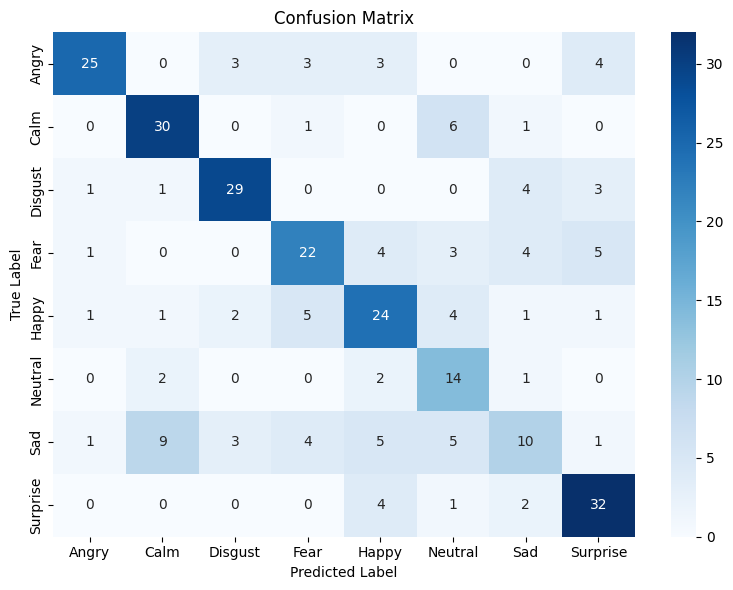

In [30]:
# ==========================================================
# 9.4 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = LightSERNet.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 9.5 Classification Report (Precision, Recall and F1-score)

In [31]:
# ==========================================================
# 9.5 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

       Angry       0.86      0.66      0.75        38
        Calm       0.70      0.79      0.74        38
     Disgust       0.78      0.76      0.77        38
        Fear       0.63      0.56      0.59        39
       Happy       0.57      0.62      0.59        39
     Neutral       0.42      0.74      0.54        19
         Sad       0.43      0.26      0.33        38
    Surprise       0.70      0.82      0.75        39

    accuracy                           0.65       288
   macro avg       0.64      0.65      0.63       288
weighted avg       0.65      0.65      0.64       288

